# Predicción de Enfermedad Cardíaca con K-NN y Árbol de Decisión

En este trabajo se utilizará un dataset de Kaggle relacionado con pacientes y factores de riesgo cardíaco.
El objetivo es aplicar modelos de aprendizaje automático supervisado para predecir si un paciente presenta enfermedad cardíaca o no.

Para ello se implementarán y compararán dos modelos de clasificación:

K-Nearest Neighbors (K-NN)
Árbol de Decisión

Además, se analizarán métricas de rendimiento, matrices de confusión y visualizaciones gráficas para interpretar el comportamiento de los modelos.

In [ ]:
# Importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cargar dataset

df = pd.read_csv('/heart.csv')

# Mostrar primeras filas
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# Información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


# Descripción de variables del dataset:

- Age: edad del paciente.
- Sex: sexo del paciente.
- ChestPainType: tipo de dolor de pecho.
- RestingBP: presión arterial en reposo.
- Cholesterol: nivel de colesterol.
- FastingBS: azúcar en sangre en ayunas.
- RestingECG: resultados del electrocardiograma.
- MaxHR: frecuencia cardíaca máxima alcanzada.
- ExerciseAngina: angina inducida por ejercicio.
- Oldpeak: depresión del segmento ST.
- ST_Slope: pendiente del segmento ST.
- HeartDisease: variable objetivo.
    
    0 = no presenta enfermedad cardíaca
    1 = presenta enfermedad cardíaca

# Preparación y preprocesamiento de datos

En esta etapa se preparan los datos para el entrenamiento de los modelos de aprendizaje automático.

Las variables categóricas serán transformadas a valores numéricos para que puedan ser utilizadas por los algoritmos K-NN y Árbol de Decisión.

In [ ]:
# Transformación de variables categóricas

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Convertimos variables categóricas a numéricas
df['Sex'] = le.fit_transform(df['Sex'])
df['ChestPainType'] = le.fit_transform(df['ChestPainType'])
df['RestingECG'] = le.fit_transform(df['RestingECG'])
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])
df['ST_Slope'] = le.fit_transform(df['ST_Slope'])

# Verificamos cambios
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


# División de datos

Se separan las variables predictoras y la variable objetivo.

Posteriormente, el dataset se divide en conjuntos de entrenamiento y prueba para evaluar correctamente el rendimiento de los modelos.

In [ ]:
# Variables predictoras y variable objetivo

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# División de datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (642, 11)
Datos de prueba: (276, 11)


# Escalado de variables

Se aplica un escalado de datos utilizando StandardScaler.

Este proceso es importante especialmente para el modelo K-NN, ya que trabaja calculando distancias entre los datos y necesita que las variables estén en escalas similares.

In [ ]:
# Escalado de datos

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Escalado realizado correctamente")

Escalado realizado correctamente


# Modelo K-Nearest Neighbors (K-NN)

Se implementa el algoritmo K-NN para clasificar si un paciente presenta enfermedad cardíaca o no.

Este modelo clasifica los datos según la cercanía entre los puntos utilizando los vecinos más próximos.

In [ ]:
# Modelo KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict(X_test_sc)

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy del modelo KNN:", accuracy_knn)

# Reporte de clasificación
print("\nReporte de clasificación KNN:\n")
print(classification_report(y_test, y_pred_knn))

Accuracy del modelo KNN: 0.8659420289855072

Reporte de clasificación KNN:

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       112
           1       0.91      0.86      0.88       164

    accuracy                           0.87       276
   macro avg       0.86      0.87      0.86       276
weighted avg       0.87      0.87      0.87       276



# Visualización de clasificación K-NN

Para representar gráficamente el funcionamiento del modelo K-NN, se utilizarán dos variables del dataset:

- MaxHR
- Oldpeak

La visualización permitirá observar cómo el algoritmo separa las clases según la cercanía entre los datos.

In [ ]:
# Seleccionamos dos variables para visualización

X_vis = df[['MaxHR', 'Oldpeak']].values
y_vis = df['HeartDisease'].values

# División de datos
from sklearn.model_selection import train_test_split

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis,
    test_size=0.3,
    random_state=42
)

# Escalado
from sklearn.preprocessing import StandardScaler

scaler_vis = StandardScaler()

X_train_vis_sc = scaler_vis.fit_transform(X_train_vis)
X_test_vis_sc = scaler_vis.transform(X_test_vis)

# Modelo KNN para visualización
knn_vis = KNeighborsClassifier(n_neighbors=5)

knn_vis.fit(X_train_vis_sc, y_train_vis)

KNeighborsClassifier()

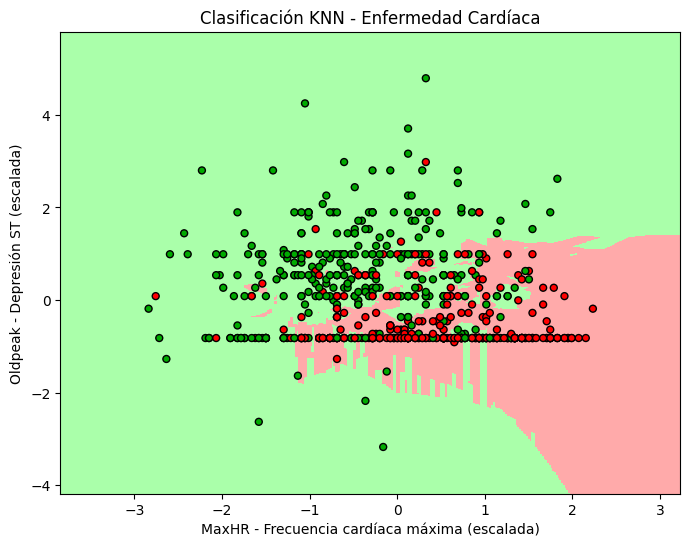

In [ ]:
# Gráfico de clasificación KNN

from matplotlib.colors import ListedColormap

h = 0.02

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ListedColormap(['#FF0000', '#00AA00'])

x_min, x_max = X_train_vis_sc[:, 0].min() - 1, X_train_vis_sc[:, 0].max() + 1
y_min, y_max = X_train_vis_sc[:, 1].min() - 1, X_train_vis_sc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

plt.scatter(
    X_train_vis_sc[:, 0],
    X_train_vis_sc[:, 1],
    c=y_train_vis,
    cmap=cmap_bold,
    edgecolor='k',
    s=25
)

plt.xlabel('MaxHR - Frecuencia cardíaca máxima (escalada)')
plt.ylabel('Oldpeak - Depresión ST (escalada)')
plt.title('Clasificación KNN - Enfermedad Cardíaca')

plt.show()

# Árbol de Decisión

Ahora se implementará el modelo Árbol de Decisión para comparar su desempeño con K-NN.

Este algoritmo genera reglas de decisión basadas en las variables del dataset para clasificar si un paciente presenta enfermedad cardíaca o no.

In [ ]:
# Modelo Árbol de Decisión

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

modelo_tree = DecisionTreeClassifier(max_depth=4, random_state=42)

modelo_tree.fit(X_train, y_train)

y_pred_tree = modelo_tree.predict(X_test)

# Accuracy
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Accuracy del modelo Árbol:", accuracy_tree)

# Reporte de clasificación
print("\nReporte de clasificación Árbol:\n")
print(classification_report(y_test, y_pred_tree))

Accuracy del modelo Árbol: 0.8369565217391305

Reporte de clasificación Árbol:

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       112
           1       0.86      0.87      0.86       164

    accuracy                           0.84       276
   macro avg       0.83      0.83      0.83       276
weighted avg       0.84      0.84      0.84       276



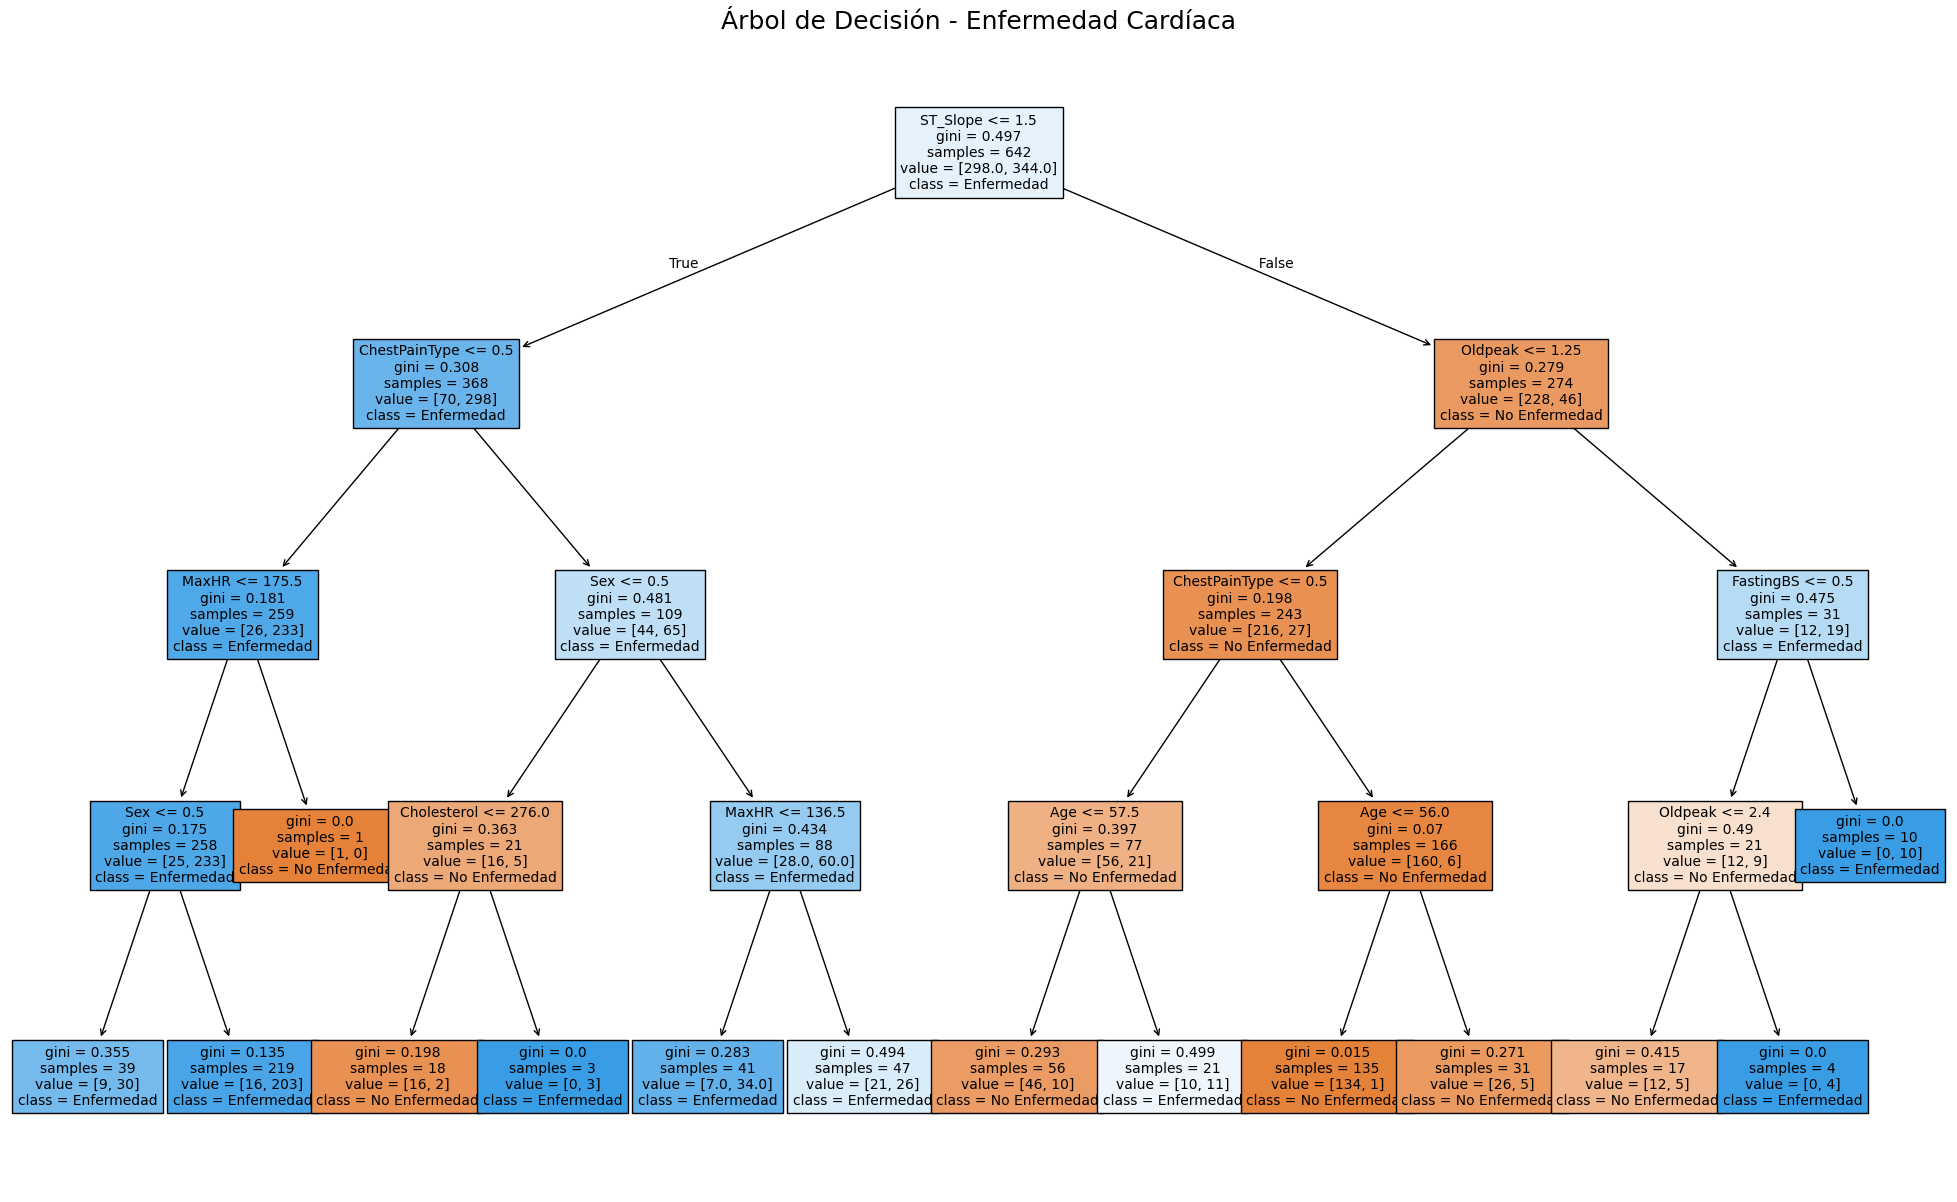

In [ ]:
# Visualización simplificada del Árbol de Decisión

from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,15))

tree.plot_tree(
    modelo_tree,
    feature_names=X.columns,
    class_names=['No Enfermedad', 'Enfermedad'],
    filled=True,
    fontsize=10
)

plt.title("Árbol de Decisión - Enfermedad Cardíaca", fontsize=18)

plt.show()

# Comparación de modelos

A continuación se comparan las matrices de confusión de K-NN y Árbol de Decisión para analizar el desempeño de ambos modelos en la clasificación de pacientes.

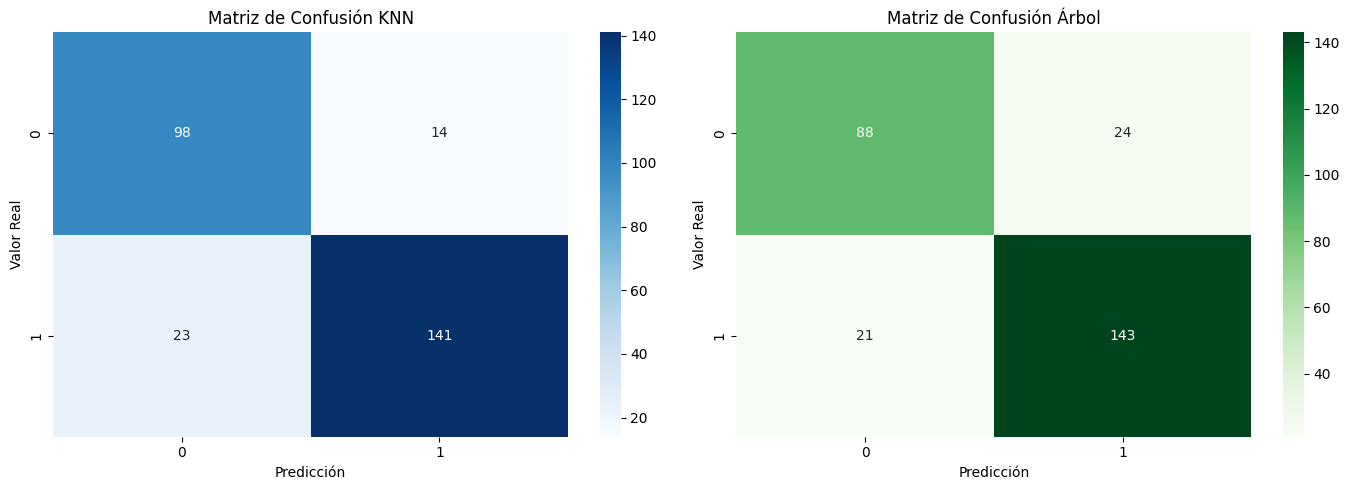

In [ ]:
# Matrices de confusión comparativas

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# KNN
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión KNN')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Valor Real')

# Árbol
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz de Confusión Árbol')
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Valor Real')

plt.tight_layout()

plt.show()

# Análisis comparativo de modelos

El modelo K-NN obtuvo un accuracy aproximado del 87%, mostrando un buen desempeño general en la clasificación de pacientes con enfermedad cardíaca.

La matriz de confusión del modelo K-NN muestra que logró clasificar correctamente una gran cantidad de casos reales, aunque todavía existen algunos errores de clasificación tanto en pacientes con enfermedad como sin enfermedad cardíaca.

Por otro lado, el modelo Árbol de Decisión obtuvo un accuracy cercano al 84%. Aunque el rendimiento fue ligeramente inferior al de K-NN, este modelo permitió interpretar de forma más clara las reglas de decisión utilizadas durante la clasificación.

Al comparar ambas matrices de confusión, se observa que los dos modelos presentan buenos resultados generales sobre el dataset seleccionado. Sin embargo, K-NN logró una cantidad ligeramente mayor de clasificaciones correctas, mientras que el Árbol de Decisión destacó por su interpretabilidad visual y facilidad para comprender cómo se toman las decisiones.

Estos resultados demuestran que ambos algoritmos pueden ser utilizados en tareas de clasificación supervisada aplicadas al área de salud, permitiendo analizar patrones relacionados con la presencia de enfermedad cardíaca.

# Conclusión Final

En conclusión, ambos modelos demostraron un buen desempeño en la clasificación de pacientes con enfermedad cardíaca utilizando el dataset seleccionado.

El modelo K-NN obtuvo una precisión ligeramente superior, mientras que el Árbol de Decisión permitió una interpretación más clara de las reglas utilizadas durante la clasificación.

Este trabajo permitió aplicar técnicas de aprendizaje automático supervisado y analizar cómo diferentes algoritmos pueden utilizarse para resolver problemas de clasificación en el área de salud.